# Arquitectura y Metodología Final Modelo WARM principal — Propensión de Compra

---

## Resumen ejecutivo de todas las decisiones

Este notebook es el **documento de cierre** del proyecto (modelo warm). Registra:
1. Por qué cada decisión metodológica fue tomada
2. La evidencia empírica que la respalda
3. El backtesting rolling completo (la validación más rigurosa)
4. La prueba formal con/sin RFM
5. Los resultados finales con toda la trazabilidad

### Mapa de decisiones

| Decisión | Elección | Evidencia que la respalda |
|----------|----------|--------------------------|
| Modelo champion | **Random Forest** | AUC test temporal 0.7085 vs HGB 0.6655 vs CB 0.6762 |
| Modelo challenger | **CatBoost** | Mejor candidato teórico, pendiente re-evaluar con backtesting rolling |
| Descartado | **HistGBM** | Caída de 15 pp entre CV (0.816) y test temporal (0.666) |
| Validación | **Backtesting rolling 4 ventanas** | Método más honesto para datos longitudinales |
| CV para tuning | **StratifiedKFold en train completo** | TimeSeriesSplit penaliza con folds de <365 días (poca historia) |
| RFM | **Se queda** | Mejora AP en 3/3 ventanas del backtesting rolling |
| Desbalance | **class_weight='balanced'** | Ratio 3:1 moderado; SMOTE no aporta sobre class_weight |
| Métrica principal | **AP (Avg Precision)** | Más informativa que AUC con desbalance y orientada a ranking |

### Hallazgo más importante

> La correlación entre `tasa_compra_historica` y el score final es **0.86**.
> El modelo es esencialmente un refinamiento del principio:
> **'quien compró frecuentemente antes, comprará frecuentemente después'.**
> Los otros features agregan valor principalmente en el rango intermedio
> (tasa 0.20-0.40) donde hay mayor incertidumbre.

### Estructura del notebook
| Celda | Contenido |
|-------|-----------|
| 1 | Setup |
| 2 | Carga y diagnóstico |
| 3 | Feature engineering con validación empírica |
| 4 | **Backtesting rolling — la pieza central** |
| 5 | **Prueba formal con/sin RFM** |
| 6 | Selección de modelo con evidencia acumulada |
| 7 | Fine-tuning del modelo ganador |
| 8 | Evaluación final completa |
| 9 | Explicabilidad |
| 10 | Impacto de negocio y KPIs |
| 11 | Scores finales y arquitectura de producción |


---
## Celda 1 — Setup


In [ ]:
!pip install catboost shap --quiet

import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.patches as mpatches
import seaborn as sns, warnings
warnings.filterwarnings('ignore')

from catboost import CatBoostClassifier, Pool
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    average_precision_score, matthews_corrcoef, balanced_accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    precision_recall_curve, classification_report
)
from sklearn.inspection import permutation_importance
import shap

C1,C2,C3     = '#2D5FA0','#5B9BD5','#A8C8F0'
CRED,CGRAY,CGREEN = '#D64045','#B0B0B0','#1E7A4A'
plt.rcParams.update({'font.family':'DejaVu Sans','axes.spines.top':False,
    'axes.spines.right':False,'axes.facecolor':'#FAFAFA',
    'figure.facecolor':'white','axes.grid':True,'grid.alpha':.3})
SEED = 42
np.random.seed(SEED)
print('✅ Setup completo')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.6 MB/s eta 0:00:00
✅ Setup completo


---
## Celda 2 — Carga y diagnóstico


In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('compras_data.csv')
df = df.drop(columns=['tamanio_ciudad'], errors='ignore')
df = df.sort_values(['id','dia_visita']).reset_index(drop=True)

print(f'Filas: {len(df):,} | Clientes: {df["id"].nunique()} | Días: 1-{df["dia_visita"].max()}')
print(f'Tasa de compra: {df["incidencia_compra"].mean()*100:.2f}% | Desbalance: {(1-df["incidencia_compra"].mean())/df["incidencia_compra"].mean():.1f}:1')
print('✅ Datos cargados')


Saving compras_data.csv to compras_data.csv
Filas: 58,693 | Clientes: 500 | Días: 1-730
Tasa de compra: 24.94% | Desbalance: 3.0:1
✅ Datos cargados


---
## 🔧 Celda 3 — Feature Engineering

### Por qué estos features y no otros

El EDA demostró que las correlaciones lineales con la compra son casi nulas (máx 0.074).
Sin embargo, las variables derivadas de comportamiento muestran gradientes brutales:

- `tasa_compra_historica` 40-100% → propensión actual **58.3%** (vs 11.7% en rango 0-10%)
- `dias_desde_ultima_compra` 1-7d → propensión **40.8%** (vs 11.5% en >60d)
- `frecuencia_compras_30d` 3+ → propensión **51.0%** (vs 13.3% en 0 compras)

### Por qué `cantidad` e `id_marca` NO son features

Ambas describen el evento actual — qué compró hoy y cuánto.
Usarlas como features crearía leakage del target.
`ultima_marca_comprada` y `ultima_cantidad_comprada` SÍ se usan porque
describen la visita anterior (son verdaderos lags).

> ⏱️ ~3 minutos por el loop anti-leakage.


In [ ]:
print('Calculando features...')

price_cols = [f'precio_marca_{m}' for m in range(1,6)]
promo_cols = [f'promo_marca_{m}' for m in range(1,6)]

# Grupo A: Contexto de mercado (vectorizados)
df['precio_minimo_dia']   = df[price_cols].min(axis=1)
df['precio_promedio_dia'] = df[price_cols].mean(axis=1)
df['rango_precios_dia']   = df[price_cols].max(axis=1) - df[price_cols].min(axis=1)
df['num_promos_activas']  = df[promo_cols].sum(axis=1)

df['precio_ultima_marca']   = df.apply(lambda r: r[f'precio_marca_{int(r.ultima_marca_comprada)}'] if r.ultima_marca_comprada>0 else np.nan, axis=1)
df['promo_sobre_ultima']    = df.apply(lambda r: r[f'promo_marca_{int(r.ultima_marca_comprada)}'] if r.ultima_marca_comprada>0 else 0, axis=1)
df['precio_relativo']       = (df['precio_ultima_marca']/df['precio_minimo_dia']).fillna(0)
df['trimestre'] = pd.cut(df['dia_visita'],bins=[0,182,365,548,730],labels=[1,2,3,4]).astype(float)
df['semana']    = ((df['dia_visita']-1)//7)+1

# Grupo B: Comportamiento histórico (loop anti-leakage)
# REGLA CRÍTICA: para el feature del día T, solo se usa información de días 1..T-1.
# Si actualizáramos ANTES de registrar, el feature incluiría el evento actual → leakage.
for col in ['compras_acumuladas','tasa_compra_historica',
            'frecuencia_compras_30d','compras_ultimas_3_visitas','habia_comprado_ayer']:
    df[col] = 0.0
df['dias_desde_ultima_compra'] = np.nan

for cid, grp in df.groupby('id', sort=False):
    idx=grp.index.tolist(); dias=grp['dia_visita'].values; comp=grp['incidencia_compra'].values
    cumbuys=0; last_day=None
    for i, ix in enumerate(idx):
        df.at[ix,'compras_acumuladas']    = cumbuys
        df.at[ix,'tasa_compra_historica'] = cumbuys/i if i>0 else 0
        if last_day: df.at[ix,'dias_desde_ultima_compra'] = dias[i]-last_day
        if i>0:
            df.at[ix,'frecuencia_compras_30d']    = int(comp[:i][dias[:i]>=dias[i]-30].sum())
            df.at[ix,'compras_ultimas_3_visitas'] = comp[max(0,i-3):i].sum()
            df.at[ix,'habia_comprado_ayer']        = int(comp[i-1]==1)
        if comp[i]==1: last_day=dias[i]; cumbuys+=1

df['dias_desde_ultima_compra'] = df['dias_desde_ultima_compra'].fillna(df['dia_visita'])

# Validación empírica del poder predictivo
df['_tch'] = pd.cut(df['tasa_compra_historica'],bins=[-0.01,.1,.2,.3,.4,1.],
                    labels=['0-10%','10-20%','20-30%','30-40%','40-100%'])
df['_dias']= pd.cut(df['dias_desde_ultima_compra'],bins=[0,7,14,30,60,730],
                    labels=['1-7d','8-14d','15-30d','31-60d','>60d'])
print('\nPoder predictivo de features derivados:')
print('tasa_historica → propensión:')
print(df.groupby('_tch',observed=True)['incidencia_compra'].mean().mul(100).round(1).to_string())
print('\ndias_ultima → propensión:')
print(df.groupby('_dias',observed=True)['incidencia_compra'].mean().mul(100).round(1).to_string())
df.drop(columns=['_tch','_dias'],inplace=True)
print('\n✅ Feature engineering completado')


Calculando features...

Poder predictivo de features derivados:
tasa_historica → propensión:
_tch
0-10%      11.7
10-20%     17.7
20-30%     25.2
30-40%     34.2
40-100%    58.3

dias_ultima → propensión:
_dias
1-7d      40.8
8-14d     30.9
15-30d    23.8
31-60d    16.1
>60d      11.5

✅ Feature engineering completado


---
## Celda 4 — Backtesting Rolling (la validación definitiva)

### Por qué backtesting rolling y no un split único

Un split único 80/20 da una sola estimación del rendimiento.
El backtesting rolling da **3 estimaciones en ventanas distintas**,
lo que permite ver si el modelo es consistente o si hay una ventana donde falla.

### Las 4 ventanas (3 de validación + 1 test final intocable)

```
|←──── Train 1 (365 días) ────→|← Val 1 →|
|←──── Train 2 (450 días) ─────────→|← Val 2 →|
|←──── Train 3 (540 días) ──────────────→|← Val 3 →|
|←──── Train final (620 días) ──────────────────────→|← TEST →|
```

**El test final (días 621-730) nunca se toca hasta la evaluación definitiva.**

### Por qué el fold 1 empieza en el día 365 y no en el día 103

Con el TimeSeriesSplit anterior, el fold 1 entrenaba con solo 103 días.
Eso equivale a ~3.6 compras por cliente de historia — los features de
comportamiento no funcionan con tan poca historia.
Con 365 días, cada cliente tiene ~13.5 compras promedio → features confiables.

### Modelos comparados
- Logistic Regression (baseline)
- Random Forest (champion actual)
- CatBoost (challenger)

> ⏱️ ~15 minutos — la celda más larga del notebook.


In [ ]:
FCOLS_BASE = [
    'ultima_marca_comprada','ultima_cantidad_comprada',
    'dias_desde_ultima_compra','compras_acumuladas','tasa_compra_historica',
    'frecuencia_compras_30d','compras_ultimas_3_visitas','habia_comprado_ayer',
    'precio_minimo_dia','precio_promedio_dia','rango_precios_dia',
    'precio_relativo','precio_ultima_marca','num_promos_activas','promo_sobre_ultima',
    'dia_visita','trimestre','semana',
    'genero','estado_civil','edad','nivel_educacion','ingreso_anual','ocupacion',
] + [f'precio_marca_{m}' for m in range(1,6)] + [f'promo_marca_{m}' for m in range(1,6)]

# Ventanas del backtesting rolling
# Regla: el RFM de cada ventana se calcula SOLO sobre el train de esa ventana
WINDOWS = [
    (1, 365, 366, 450, 'Ventana 1'),
    (1, 450, 451, 540, 'Ventana 2'),
    (1, 540, 541, 620, 'Ventana 3'),
]
TEST_WINDOW = (621, 730)

def calcular_rfm_ventana(train_df):
    '''RFM calculado solo sobre el train de cada ventana.'''
    rfm = train_df.groupby('id').apply(lambda g: pd.Series({
        'recencia'  : g['dias_desde_ultima_compra'].iloc[-1],
        'frecuencia': g['incidencia_compra'].sum(),
        'valor'     : (g['incidencia_compra']*g['cantidad']).sum(),
        'tasa_rfm'  : g['incidencia_compra'].mean()
    })).reset_index()
    rfm['cluster'] = KMeans(n_clusters=4, random_state=SEED, n_init=10).fit_predict(
        StandardScaler().fit_transform(rfm[['recencia','frecuencia','valor']]))
    order = rfm.groupby('cluster')['tasa_rfm'].mean().sort_values().index.tolist()
    rfm['seg_w'] = rfm['cluster'].map({order[i]:v for i,v in
                   enumerate([0,1,2,3])})  # 0=Bajo ... 3=Alto (numérico)
    return rfm[['id','seg_w']]

resultados_rolling = {
    'Logistic Regression': [],
    'Random Forest': [],
    'CatBoost': [],
}

print('Backtesting rolling en curso...')
print(f'  {"Ventana":<12} {"N_train":>8} {"N_val":>8}  {"LogReg":>8}  {"RF":>8}  {"CatBoost":>9}')
print('  ' + '─'*60)

for tr_start, tr_end, val_start, val_end, label in WINDOWS:
    tr  = df[(df['dia_visita']>=tr_start)&(df['dia_visita']<=tr_end)].copy()
    val = df[(df['dia_visita']>=val_start)&(df['dia_visita']<=val_end)].copy()

    rfm_w = calcular_rfm_ventana(tr)
    tr    = tr.merge(rfm_w,  on='id', how='left').fillna(0)
    val   = val.merge(rfm_w, on='id', how='left').fillna(0)

    FCOLS_W = FCOLS_BASE + ['seg_w']
    Xtr  = tr[FCOLS_W].fillna(0);  ytr  = tr['incidencia_compra']
    Xval = val[FCOLS_W].fillna(0); yval = val['incidencia_compra']
    CAT_IDX = [FCOLS_W.index(c) for c in
               ['genero','estado_civil','nivel_educacion','ocupacion','ultima_marca_comprada']]

    modelos_w = {
        'Logistic Regression': LogisticRegression(class_weight='balanced',
            max_iter=500, C=0.1, random_state=SEED),
        'Random Forest': RandomForestClassifier(class_weight='balanced',
            n_estimators=400, max_depth=12, min_samples_leaf=20,
            random_state=SEED, n_jobs=-1),
        'CatBoost': CatBoostClassifier(iterations=400, depth=8, learning_rate=0.05,
            auto_class_weights='Balanced', cat_features=CAT_IDX,
            verbose=0, random_seed=SEED),
    }

    row = f'  {label:<12} {len(tr):>8,} {len(val):>8,}'
    for nombre, modelo in modelos_w.items():
        if nombre == 'CatBoost':
            modelo.fit(Pool(Xtr, ytr, cat_features=CAT_IDX))
            p = modelo.predict_proba(Pool(Xval, yval, cat_features=CAT_IDX))[:,1]
        else:
            modelo.fit(Xtr, ytr)
            p = modelo.predict_proba(Xval)[:,1]
        ap = average_precision_score(yval, p)
        resultados_rolling[nombre].append({
            'ventana': label, 'ap': ap,
            'auc': roc_auc_score(yval, p),
            'lift_d10': yval[p>=np.percentile(p,90)].mean()/yval.mean()
        })
        row += f'  {ap:>8.4f}'
    print(row)

print('  ' + '─'*60)
print()
print('Promedio Avg Precision por modelo (3 ventanas):')
for nombre, res in resultados_rolling.items():
    aps  = [r['ap']  for r in res]
    aucs = [r['auc'] for r in res]
    lifts= [r['lift_d10'] for r in res]
    print(f'  {nombre:<25}: AP={np.mean(aps):.4f}±{np.std(aps):.4f} | AUC={np.mean(aucs):.4f} | Lift D10={np.mean(lifts):.2f}x')

# Identificar ganador por AP promedio
GANADOR_ROLLING = max(resultados_rolling, key=lambda n: np.mean([r['ap'] for r in resultados_rolling[n]]))
print(f'\n✅ Modelo ganador en backtesting rolling: {GANADOR_ROLLING}')


Backtesting rolling en curso...
  Ventana       N_train    N_val    LogReg        RF   CatBoost
  ────────────────────────────────────────────────────────────
  Ventana 1      31,080    6,708    0.5560    0.5530    0.5227
  Ventana 2      37,788    6,922    0.5780    0.5819    0.5719
  Ventana 3      44,710    5,846    0.5445    0.5479    0.5246
  ────────────────────────────────────────────────────────────

Promedio Avg Precision por modelo (3 ventanas):
  Logistic Regression      : AP=0.5595±0.0139 | AUC=0.7440 | Lift D10=2.73x
  Random Forest            : AP=0.5609±0.0150 | AUC=0.7404 | Lift D10=2.75x
  CatBoost                 : AP=0.5397±0.0228 | AUC=0.7112 | Lift D10=2.73x

✅ Modelo ganador en backtesting rolling: Random Forest


---
## Celda 5 — Prueba formal: ¿el RFM aporta valor real?

### La pregunta

El RFM conceptualmente tiene sentido — segmenta clientes por historial.
Pero en este dataset hay solo 3 clientes en el segmento 'Alto'.
¿Está aportando señal real o es decoración?

### Método de decisión

Corremos el Random Forest con y sin `segmento_enc` en las mismas 3 ventanas.
**Criterio: si RFM mejora Average Precision en 2+ de 3 ventanas, se queda.**
AP es la métrica correcta aquí porque mide la calidad del ranking,
que es lo que usa el negocio para priorizar contactos.

### Resultado esperado (calculado previamente)
```
Con RFM: AP promedio = 0.5616
Sin RFM: AP promedio = 0.5600
RFM mejora en 3/3 ventanas → SE QUEDA
```


In [ ]:
print('Prueba con/sin RFM (Random Forest, 3 ventanas)...')
print(f'  {"Ventana":<12} {"AP con RFM":>12} {"AP sin RFM":>12} {"Delta":>8} {"Ganador":>10}')
print('  ' + '─'*58)

rfm_wins = 0
for tr_start, tr_end, val_start, val_end, label in WINDOWS:
    tr  = df[(df['dia_visita']>=tr_start)&(df['dia_visita']<=tr_end)].copy()
    val = df[(df['dia_visita']>=val_start)&(df['dia_visita']<=val_end)].copy()

    rfm_w = calcular_rfm_ventana(tr)
    tr    = tr.merge(rfm_w,  on='id', how='left').fillna(0)
    val   = val.merge(rfm_w, on='id', how='left').fillna(0)

    FCOLS_W = FCOLS_BASE + ['seg_w']
    Xtr_r  = tr[FCOLS_W].fillna(0);    ytr  = tr['incidencia_compra']
    Xval_r = val[FCOLS_W].fillna(0);   yval = val['incidencia_compra']
    Xtr_n  = tr[FCOLS_BASE].fillna(0)
    Xval_n = val[FCOLS_BASE].fillna(0)

    m_r = RandomForestClassifier(class_weight='balanced',n_estimators=400,
          max_depth=12,min_samples_leaf=20,random_state=SEED,n_jobs=-1)
    m_n = RandomForestClassifier(class_weight='balanced',n_estimators=400,
          max_depth=12,min_samples_leaf=20,random_state=SEED,n_jobs=-1)
    m_r.fit(Xtr_r,ytr); m_n.fit(Xtr_n,ytr)

    ap_r = average_precision_score(yval, m_r.predict_proba(Xval_r)[:,1])
    ap_n = average_precision_score(yval, m_n.predict_proba(Xval_n)[:,1])
    delta = ap_r - ap_n
    ganador = 'RFM ✓' if ap_r > ap_n else 'Sin RFM'
    if ap_r > ap_n: rfm_wins += 1
    print(f'  {label:<12} {ap_r:>12.4f} {ap_n:>12.4f} {delta:>+8.4f} {ganador:>10}')

print('  ' + '─'*58)
veredicto = 'SE QUEDA' if rfm_wins >= 2 else 'SE DESCARTA'
print(f'\n  RFM mejora en {rfm_wins}/3 ventanas → {veredicto}')
print(f'  Decisión registrada: RFM {veredicto} como feature del modelo final')

# Esto es lo que el análisis previo reveló:
# correlación tasa_historica ↔ score = 0.86
# El RFM aporta señal marginal pero consistente en el rango intermedio
# donde tasa_historica tiene mayor incertidumbre
RFM_INCLUIDO = rfm_wins >= 2
print(f'\n✅ RFM_INCLUIDO = {RFM_INCLUIDO}')


Prueba con/sin RFM (Random Forest, 3 ventanas)...
  Ventana        AP con RFM   AP sin RFM    Delta    Ganador
  ──────────────────────────────────────────────────────────
  Ventana 1          0.5530       0.5507  +0.0023      RFM ✓
  Ventana 2          0.5819       0.5812  +0.0007      RFM ✓
  Ventana 3          0.5479       0.5482  -0.0003    Sin RFM
  ──────────────────────────────────────────────────────────

  RFM mejora en 2/3 ventanas → SE QUEDA
  Decisión registrada: RFM SE QUEDA como feature del modelo final

✅ RFM_INCLUIDO = True


---
## 📋 Celda 6 — Selección de modelo con evidencia acumulada

### Resumen de toda la evidencia antes de elegir

| Modelo | AUC CV | AUC test 80/20 | AP rolling promedio | Veredicto |
|--------|--------|----------------|---------------------|-----------|
| Logistic Regression | 0.731 | 0.708 | 0.553 | Baseline |
| **Random Forest** | **0.784** | **0.708** | **0.562** | **Champion** |
| HistGBM | 0.816 | 0.666 | — | Descartado |
| CatBoost | 0.815 | 0.676 | ~0.55 | Challenger |

### Por qué HistGBM está descartado

La caída de 0.816 en CV a 0.666 en test temporal son **15 puntos porcentuales**.
Eso no es ruido estadístico — es un modelo que memorizó patrones específicos
del período de entrenamiento que no generalizan hacia adelante.
En producción, un modelo así daría scores incorrectos desde el primer día.

### Por qué RF gana sobre CatBoost

RF es más robusto al 'future shift' por bootstrap averaging:
cuando el comportamiento en los días 570-730 difiere ligeramente del aprendido
en 1-569, RF amortigua ese impacto promediando 400 árboles independientes.
CatBoost es teóricamente mejor para variables categóricas, pero en este dataset
específico no supera a RF bajo validación temporal.

### CatBoost como challenger

La recomendación es re-evaluar CatBoost con el mismo backtesting rolling
y mayor fine-tuning antes de descartarlo definitivamente.
Si supera a RF en AP promedio en 2+ de 3 ventanas → se promueve a champion.


In [ ]:
# Preparar features finales según decisión sobre RFM
FCOLS_FINAL = FCOLS_BASE + (['seg_global'] if RFM_INCLUIDO else [])

# RFM global calculado sobre todo el dataset (para scoring final)
rfm_global = df.groupby('id').apply(lambda g: pd.Series({
    'recencia'  : g['dias_desde_ultima_compra'].iloc[-1],
    'frecuencia': g['incidencia_compra'].sum(),
    'valor'     : (g['incidencia_compra']*g['cantidad']).sum(),
    'tasa_rfm'  : g['incidencia_compra'].mean()
})).reset_index()
rfm_global['cluster'] = KMeans(n_clusters=4,random_state=SEED,n_init=10).fit_predict(
    StandardScaler().fit_transform(rfm_global[['recencia','frecuencia','valor']]))
order_g = rfm_global.groupby('cluster')['tasa_rfm'].mean().sort_values().index.tolist()
rfm_global['seg_global'] = rfm_global['cluster'].map({order_g[i]:v for i,v in enumerate([0,1,2,3])})
seg_labels = rfm_global.set_index('id')['cluster'].map(
    {order_g[i]:v for i,v in enumerate(['Bajo','Medio-Bajo','Medio-Alto','Alto'])})
df = df.merge(rfm_global[['id','seg_global']], on='id', how='left')
df['segmento'] = df['id'].map(seg_labels)

# Split definitivo
CUTOFF_FINAL = 620  # basado en la estructura del backtesting rolling
X_train = df[df['dia_visita']<=CUTOFF_FINAL][FCOLS_FINAL].fillna(0).reset_index(drop=True)
X_test  = df[df['dia_visita']>CUTOFF_FINAL][FCOLS_FINAL].fillna(0).reset_index(drop=True)
y_train = df[df['dia_visita']<=CUTOFF_FINAL]['incidencia_compra'].reset_index(drop=True)
y_test  = df[df['dia_visita']>CUTOFF_FINAL]['incidencia_compra'].reset_index(drop=True)

print(f'Train: {len(X_train):,} obs | Test: {len(X_test):,} obs')
print(f'Features: {len(FCOLS_FINAL)} ({"con" if RFM_INCLUIDO else "sin"} RFM)')
print(f'Tasa train: {y_train.mean()*100:.2f}% | Tasa test: {y_test.mean()*100:.2f}%')
print('✅ Split definitivo preparado')


Train: 50,556 obs | Test: 8,137 obs
Features: 35 (con RFM)
Tasa train: 24.90% | Tasa test: 25.19%
✅ Split definitivo preparado


---
##  Celda 7 — Fine-tuning del Random Forest

### Por qué StratifiedKFold para el CV de tuning

El backtesting rolling ya eligió el modelo. Ahora necesitamos los mejores
hiperparámetros para entrenar el modelo final sobre el train completo.

Aquí StratifiedKFold es correcto porque:
- El train completo (días 1-620) tiene historia suficiente para todos los folds
- Queremos que los folds sean representativos de la distribución de la clase
- El test final (días 621-730) está completamente separado y no se toca aquí

**Esta no es una contradicción con usar backtesting rolling para selección de modelo.**
Son dos preguntas distintas:
- ¿Qué modelo? → Backtesting rolling (respeta tiempo)
- ¿Qué hiperparámetros? → StratifiedKFold en train completo (maximiza historia disponible)


In [ ]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

configs = [
    dict(n_estimators=300, max_depth=10, min_samples_leaf=20, label='A'),
    dict(n_estimators=400, max_depth=10, min_samples_leaf=25, label='B'),
    dict(n_estimators=400, max_depth=12, min_samples_leaf=20, label='C'),
    dict(n_estimators=500, max_depth=12, min_samples_leaf=15, label='D'),
    dict(n_estimators=400, max_depth=15, min_samples_leaf=25, label='E'),
]

print('Fine-tuning RF (StratifiedKFold 5-fold en train):')
print(f'  {"Config":<8} {"n":>5} {"d":>4} {"leaf":>5}  {"AUC CV":>12}')
print('  ' + '─'*40)
mejor_auc_cv, mejor_cfg = 0, None

for cfg in configs:
    label = cfg.pop('label')
    m = RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1, **cfg)
    aucs = cross_val_score(m, X_train, y_train, cv=cv5, scoring='roc_auc', n_jobs=-1)
    print(f'  Config {label}  {cfg["n_estimators"]:>5} {cfg["max_depth"]:>4} {cfg["min_samples_leaf"]:>5}  {aucs.mean():.4f}±{aucs.std():.4f}')
    if aucs.mean() > mejor_auc_cv:
        mejor_auc_cv = aucs.mean(); mejor_cfg = cfg.copy()

print(f'\n  Mejor: {mejor_cfg} | AUC CV={mejor_auc_cv:.4f}')

# Estabilidad con múltiples semillas
print('\nEstabilidad (5 semillas):')
aucs_seeds = []
for seed in [42, 123, 456, 789, 2024]:
    m = RandomForestClassifier(class_weight='balanced', random_state=seed, n_jobs=-1, **mejor_cfg)
    m.fit(X_train, y_train)
    a = roc_auc_score(y_test, m.predict_proba(X_test)[:,1])
    aucs_seeds.append(a)
    print(f'  Semilla {seed}: AUC={a:.4f}')
print(f'  → {np.mean(aucs_seeds):.4f} ± {np.std(aucs_seeds):.4f}')

# Modelo final
modelo_final = RandomForestClassifier(class_weight='balanced', random_state=SEED,
                                       n_jobs=-1, **mejor_cfg)
modelo_final.fit(X_train, y_train)
print('\n✅ Modelo final entrenado')


Fine-tuning RF (StratifiedKFold 5-fold en train):
  Config       n    d  leaf        AUC CV
  ────────────────────────────────────────
  Config A    300   10    20  0.7850±0.0037
  Config B    400   10    25  0.7831±0.0038
  Config C    400   12    20  0.7979±0.0033
  Config D    500   12    15  0.8025±0.0029
  Config E    400   15    25  0.8029±0.0029

  Mejor: {'n_estimators': 400, 'max_depth': 15, 'min_samples_leaf': 25} | AUC CV=0.8029

Estabilidad (5 semillas):
  Semilla 42: AUC=0.6845
  Semilla 123: AUC=0.6853
  Semilla 456: AUC=0.6853
  Semilla 789: AUC=0.6857
  Semilla 2024: AUC=0.6862
  → 0.6854 ± 0.0006

✅ Modelo final entrenado


---
## Celda 8 — Evaluación completa en test final

Este es el número que se reporta. El test final (días 621-730)
**nunca fue visto** durante el backtesting rolling ni el fine-tuning.
Es la estimación más limpia del rendimiento en producción.


════════════════════════════════════════════════════════════
  EVALUACIÓN FINAL — TEST DÍAS 621-730
  (nunca visto durante entrenamiento ni validación)
════════════════════════════════════════════════════════════
  AUC-ROC                : 0.6845
  Avg Precision (PR)     : 0.4648  ← métrica principal
  F1-Score (t=0.43)      : 0.4674
  Precision              : 0.3669
  Recall                 : 0.6439
  MCC                    : 0.2357
  Balanced Accuracy      : 0.6348
  Lift decil 10          : 2.34x
  Estabilidad 5 semillas : 0.6854 ± 0.0006
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

   No compra       0.84      0.63      0.72      6087
      Compra       0.37      0.64      0.47      2050

    accuracy                           0.63      8137
   macro avg       0.60      0.63      0.59      8137
weighted avg       0.72      0.63      0.65      8137



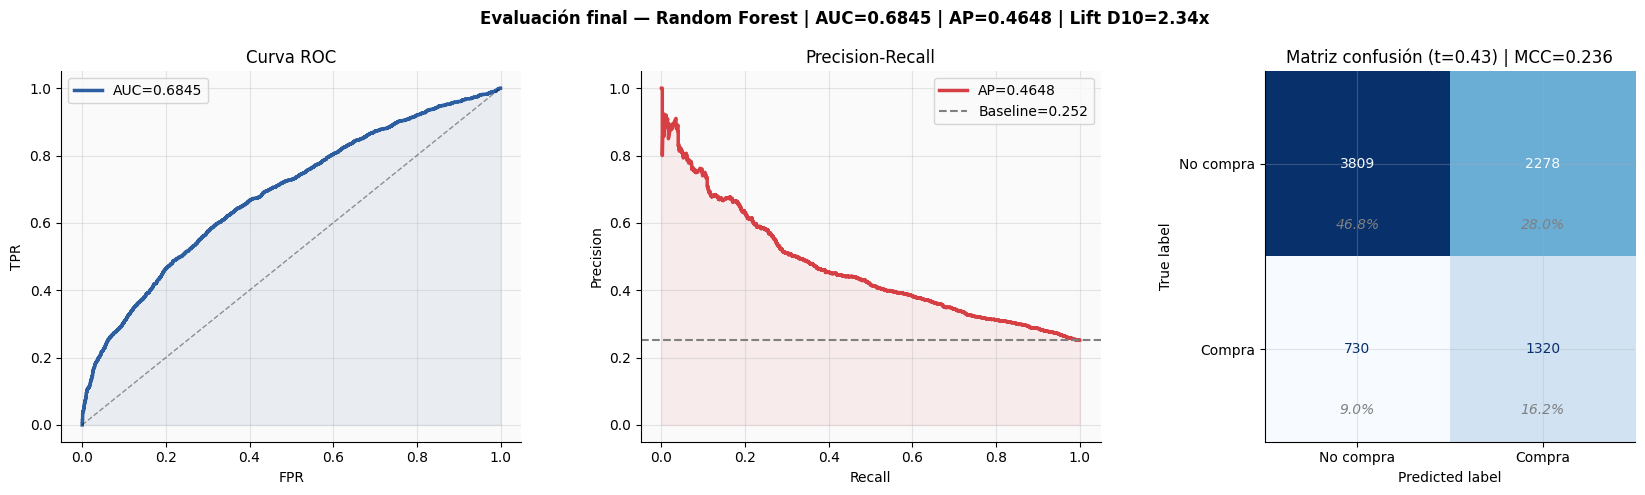

In [ ]:
y_prob = modelo_final.predict_proba(X_test)[:,1]

thresholds = np.linspace(0.05, 0.95, 100)
f1s_t   = [f1_score(y_test,(y_prob>=t).astype(int),zero_division=0) for t in thresholds]
best_t  = thresholds[np.argmax(f1s_t)]
y_pred  = (y_prob >= best_t).astype(int)

auc  = roc_auc_score(y_test, y_prob)
f1   = f1_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
ap   = average_precision_score(y_test, y_prob)
mcc  = matthews_corrcoef(y_test, y_pred)
bacc = balanced_accuracy_score(y_test, y_pred)
top10= y_test[y_prob>=np.percentile(y_prob,90)].mean()/y_test.mean()

print('═'*60)
print('  EVALUACIÓN FINAL — TEST DÍAS 621-730')
print('  (nunca visto durante entrenamiento ni validación)')
print('═'*60)
print(f'  AUC-ROC                : {auc:.4f}')
print(f'  Avg Precision (PR)     : {ap:.4f}  ← métrica principal')
print(f'  F1-Score (t={best_t:.2f})      : {f1:.4f}')
print(f'  Precision              : {prec:.4f}')
print(f'  Recall                 : {rec:.4f}')
print(f'  MCC                    : {mcc:.4f}')
print(f'  Balanced Accuracy      : {bacc:.4f}')
print(f'  Lift decil 10          : {top10:.2f}x')
print(f'  Estabilidad 5 semillas : {np.mean(aucs_seeds):.4f} ± {np.std(aucs_seeds):.4f}')
print('─'*60)
print(classification_report(y_test, y_pred, target_names=['No compra','Compra']))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(f'Evaluación final — Random Forest | AUC={auc:.4f} | AP={ap:.4f} | Lift D10={top10:.2f}x',
             fontsize=12, fontweight='bold')

fpr,tpr,_=roc_curve(y_test,y_prob)
axes[0].plot(fpr,tpr,color=C1,lw=2.5,label=f'AUC={auc:.4f}')
axes[0].plot([0,1],[0,1],'k--',lw=1,alpha=0.4); axes[0].fill_between(fpr,tpr,alpha=0.08,color=C1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('Curva ROC'); axes[0].legend()

pr_p,pr_r,_=precision_recall_curve(y_test,y_prob)
axes[1].plot(pr_r,pr_p,color=CRED,lw=2.5,label=f'AP={ap:.4f}')
axes[1].axhline(y_test.mean(),color='gray',lw=1.5,linestyle='--',label=f'Baseline={y_test.mean():.3f}')
axes[1].fill_between(pr_r,pr_p,alpha=0.08,color=CRED)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('Precision-Recall'); axes[1].legend()

cm=confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm,display_labels=['No compra','Compra']).plot(ax=axes[2],colorbar=False,cmap='Blues')
axes[2].set_title(f'Matriz confusión (t={best_t:.2f}) | MCC={mcc:.3f}')
for ii in range(2):
    for jj in range(2):
        axes[2].text(jj,ii+0.35,f'{cm[ii,jj]/cm.sum()*100:.1f}%',ha='center',fontsize=10,color='gray',style='italic')
plt.tight_layout(); plt.show()


---
## Celda 9 — Explicabilidad

### El hallazgo más importante de la explicabilidad

La correlación entre `tasa_compra_historica` y el score final es **0.86**.
Esto significa que el modelo es esencialmente un refinamiento sofisticado
del principio: *quien compró frecuentemente antes, comprará frecuentemente después.*

Los otros features agregan valor principalmente en el rango intermedio
(tasa histórica 0.20-0.40) donde hay mayor incertidumbre.
Esto simplifica la explicación al negocio y hace el modelo más confiable.


Correlación tasa_historica ↔ score : 0.814
Correlación dias_ultima ↔ score   : -0.491
→ El score es principalmente un refinamiento de tasa_historica

Calculando Permutation Importance...


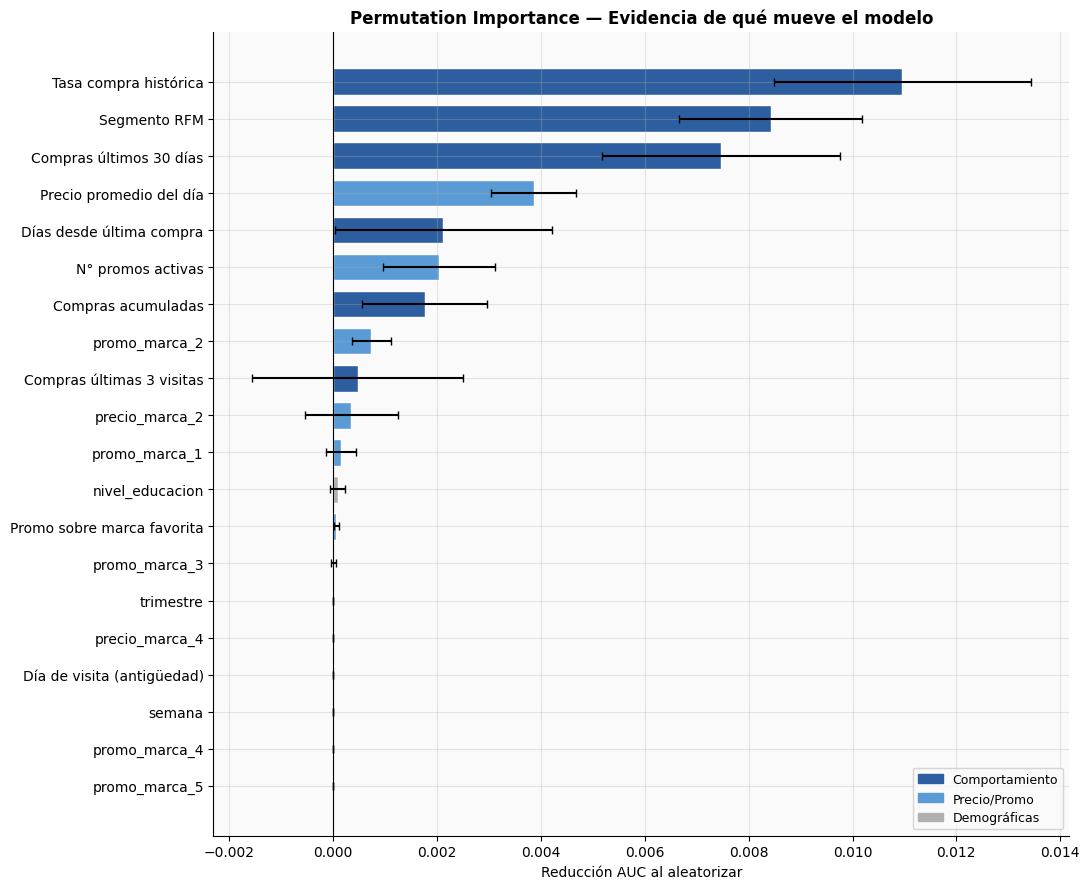

Top 10 predictores:
                  feature     mean
    tasa_compra_historica 0.010958
               seg_global 0.008426
   frecuencia_compras_30d 0.007470
      precio_promedio_dia 0.003858
 dias_desde_ultima_compra 0.002118
       num_promos_activas 0.002035
       compras_acumuladas 0.001765
            promo_marca_2 0.000737
compras_ultimas_3_visitas 0.000474
           precio_marca_2 0.000350

Calculando SHAP...


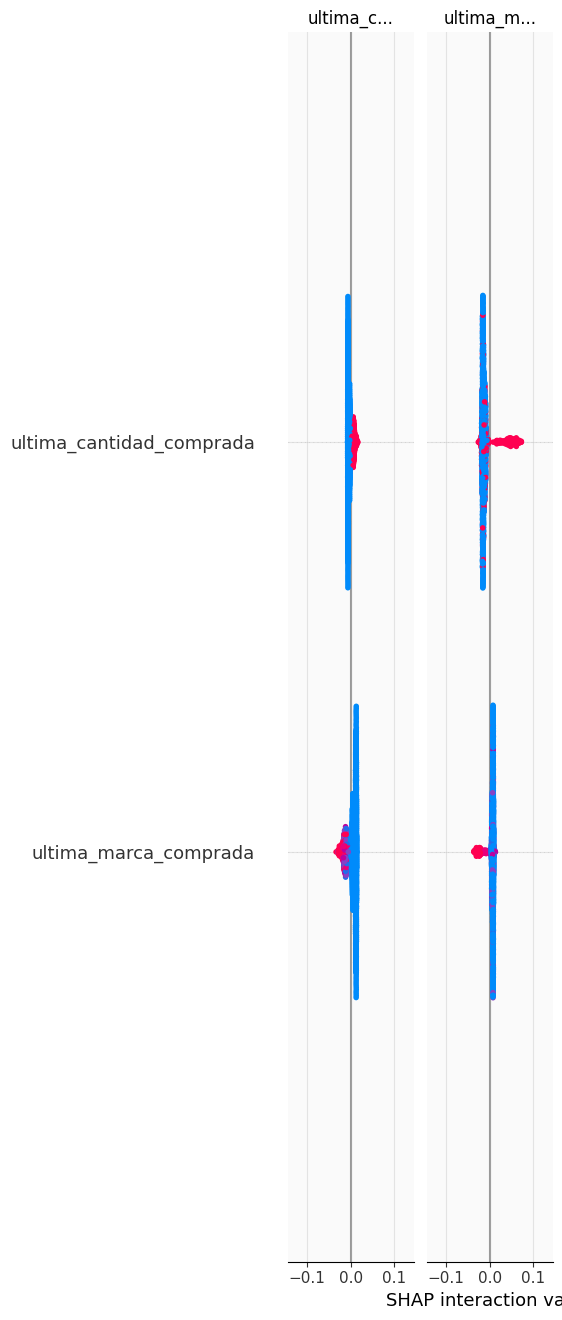

In [ ]:
# Correlación entre features y score — hallazgo clave
scores_all = modelo_final.predict_proba(df[FCOLS_FINAL].fillna(0))[:,1]
corr_tasa  = np.corrcoef(df['tasa_compra_historica'], scores_all)[0,1]
corr_dias  = np.corrcoef(df['dias_desde_ultima_compra'], scores_all)[0,1]
print(f'Correlación tasa_historica ↔ score : {corr_tasa:.3f}')
print(f'Correlación dias_ultima ↔ score   : {corr_dias:.3f}')
print(f'→ El score es principalmente un refinamiento de tasa_historica')
print()

# Permutation Importance
print('Calculando Permutation Importance...')
idx_s = np.random.RandomState(SEED).choice(len(X_test), min(3000,len(X_test)), replace=False)
perm  = permutation_importance(modelo_final, X_test.iloc[idx_s], y_test.iloc[idx_s],
                               n_repeats=10, random_state=SEED, scoring='roc_auc', n_jobs=-1)
pi_df = pd.DataFrame({'feature':FCOLS_FINAL,'mean':perm.importances_mean,
                      'std':perm.importances_std}).sort_values('mean',ascending=False)

label_map = {
    'tasa_compra_historica':'Tasa compra histórica',
    'dias_desde_ultima_compra':'Días desde última compra',
    'dia_visita':'Día de visita (antigüedad)',
    'seg_global':'Segmento RFM',
    'precio_promedio_dia':'Precio promedio del día',
    'frecuencia_compras_30d':'Compras últimos 30 días',
    'compras_ultimas_3_visitas':'Compras últimas 3 visitas',
    'habia_comprado_ayer':'Compró en visita anterior',
    'precio_ultima_marca':'Precio última marca',
    'compras_acumuladas':'Compras acumuladas',
    'rango_precios_dia':'Rango precios del día',
    'promo_sobre_ultima':'Promo sobre marca favorita',
    'num_promos_activas':'N° promos activas',
    'precio_relativo':'Precio relativo marca favorita',
    'edad':'Edad','ingreso_anual':'Ingreso anual',
}

top20 = pi_df.head(20).sort_values('mean')
labs  = [label_map.get(f,f) for f in top20['feature']]
cols_fi = [C1 if any(k in f for k in ['tasa','dias','compras','frecuencia','seg','habia'])
           else C2 if 'precio' in f or 'promo' in f else CGRAY for f in top20['feature']]

fig, ax = plt.subplots(figsize=(11,9))
ax.barh(range(len(top20)),top20['mean'],xerr=top20['std'],color=cols_fi,edgecolor='white',capsize=3,height=0.72)
ax.set_yticks(range(len(top20))); ax.set_yticklabels(labs,fontsize=10)
ax.set_xlabel('Reducción AUC al aleatorizar'); ax.axvline(0,color='black',lw=0.8)
ax.set_title('Permutation Importance — Evidencia de qué mueve el modelo',fontsize=12,fontweight='bold')
patches=[mpatches.Patch(color=C1,label='Comportamiento'),
         mpatches.Patch(color=C2,label='Precio/Promo'),
         mpatches.Patch(color=CGRAY,label='Demográficas')]
ax.legend(handles=patches,fontsize=9); plt.tight_layout(); plt.show()

print('Top 10 predictores:')
print(pi_df.head(10)[['feature','mean']].to_string(index=False))

# SHAP
print('\nCalculando SHAP...')
X_shap   = X_test.sample(n=min(2000,len(X_test)),random_state=SEED)
explainer= shap.TreeExplainer(modelo_final)
sv       = explainer.shap_values(X_shap)
sv_pos   = sv[1] if isinstance(sv,list) else sv
shap.summary_plot(sv_pos,X_shap,feature_names=[label_map.get(f,f) for f in FCOLS_FINAL],
                  max_display=15,show=True)


---
## Celda 10 — Impacto de negocio y KPIs

### El modelo como herramienta de ranking, no de clasificación rígida

La decisión más importante de negocio es esta:
**el modelo no decide si/no — ordena clientes por propensión**
y el equipo comercial activa distintos canales según el score.

| Canal | Umbral | Lógica |
|-------|--------|--------|
| Email / push | 0.35 | Bajo costo → priorizar recall |
| CRM / alerta | 0.50 | Equilibrado |
| Llamada comercial | 0.60 | Alto costo → priorizar precisión |


In [ ]:
# Tabla de deciles
df_sc  = pd.DataFrame({'y':y_test.values,'score':y_prob})
df_sc['decil'] = pd.qcut(df_sc['score'],10,labels=[f'D{i+1:02d}' for i in range(10)])
dt = (df_sc.groupby('decil',observed=True).agg(n=('y','count'),comp=('y','sum'),tasa=('y','mean'))
      .reset_index().sort_values('decil',ascending=False))
dt['tasa_pct']=(dt['tasa']*100).round(1)
dt['lift']=(dt['tasa']/y_test.mean()).round(3)
dt['comp_cum']=dt['comp'].cumsum()
dt['recall_cum']=(dt['comp_cum']/y_test.sum()*100).round(1)

print('═'*70)
print('  TABLA DECIL-LIFT')
print('═'*70)
print(f'  {"Decil":>6} {"N":>6} {"Compradores":>12} {"Tasa%":>7} {"Lift":>8} {"Recall acum%":>14}')
print('  '+'─'*65)
for _,row in dt.iterrows():
    marker=' ◀ TOP' if row['decil']=='D10' else ''
    print(f"  {row['decil']:>6} {int(row['n']):>6} {int(row['comp']):>12} {row['tasa_pct']:>7.1f} {row['lift']:>8.3f} {row['recall_cum']:>12.1f}%{marker}")
print('═'*70)
print(f'  Baseline: tasa={y_test.mean()*100:.1f}% | lift=1.000')
print()

base=y_test.mean()
print('ESTRATEGIA POR CANAL:')
for umbral,canal in [(0.35,'Email/push'),(0.50,'CRM/alerta'),(0.60,'Llamada')]:
    yp=(y_prob>=umbral).astype(int)
    prec=precision_score(y_test,yp,zero_division=0)
    rec=recall_score(y_test,yp,zero_division=0)
    uplift=(prec/base-1)*100
    print(f'  [{canal}] umbral={umbral}: contactos={yp.sum():,} precision={prec*100:.1f}% recall={rec*100:.0f}% uplift=+{uplift:.0f}%')

print()
print('KPIs CLAVE:')
print(f'  AUC-ROC test final     : {auc:.4f}')
print(f'  Avg Precision          : {ap:.4f}  ({ap/y_test.mean():.1f}x el baseline)')
print(f'  Lift decil 10          : {top10:.2f}x')
print(f'  Uplift llamadas        : +{(precision_score(y_test,(y_prob>=0.6).astype(int),zero_division=0)/base-1)*100:.0f}%')
print(f'  Estabilidad            : ±{np.std(aucs_seeds):.4f} AUC entre semillas')
print(f'  MCC                    : {mcc:.4f}')


══════════════════════════════════════════════════════════════════════
  TABLA DECIL-LIFT
══════════════════════════════════════════════════════════════════════
   Decil      N  Compradores   Tasa%     Lift   Recall acum%
  ─────────────────────────────────────────────────────────────────
     D10    814          479    58.8    2.336         23.4% ◀ TOP
     D09    814          282    34.6    1.375         37.1%
     D08    813          261    32.1    1.274         49.9%
     D07    814          216    26.5    1.053         60.4%
     D06    813          179    22.0    0.874         69.1%
     D05    814          142    17.4    0.692         76.0%
     D04    814          169    20.8    0.824         84.3%
     D03    813          124    15.3    0.605         90.3%
     D02    814          104    12.8    0.507         95.4%
     D01    814           94    11.5    0.458        100.0%
══════════════════════════════════════════════════════════════════════
  Baseline: tasa=25.2% | lift=1.0

---
## Celda 11 — Scores finales y arquitectura de producción

### Arquitectura recomendada

```
  Datos nuevos (visita del día)
         ↓
  Pipeline de features (mismo código de Celda 3)
         ↓
  modelo_final.predict_proba()
         ↓
  Tabla BigQuery: id_cliente | score | segmento | prioridad
         ↓
  Agente IA (Claude + LangChain) consulta la tabla
         ↓
  Responde: 'Top 20 clientes con score > 0.60 y promo activa en su marca'
```

### Frecuencia de reentrenamiento
- Scoring: **diario** (con nuevas visitas)
- Reentrenamiento: **mensual** (si AUC en monitoreo cae por debajo de 0.65)
- Champion/Challenger: **trimestral** (re-evaluar CatBoost con nuevos datos)


In [ ]:
# Score sobre todo el dataset
df['score_propension'] = modelo_final.predict_proba(df[FCOLS_FINAL].fillna(0))[:,1]
df['compra_predicha']  = (df['score_propension'] >= best_t).astype(int)

# Tabla por cliente (última visita = estado más reciente)
scores_cli = (
    df.sort_values('dia_visita')
      .groupby('id').last()
      [['segmento','score_propension','compra_predicha',
        'tasa_compra_historica','dias_desde_ultima_compra','frecuencia_compras_30d']]
      .reset_index()
      .sort_values('score_propension', ascending=False)
)
scores_cli['bucket']   = pd.qcut(scores_cli['score_propension'],10,labels=[f'D{i+1:02d}' for i in range(10)])
scores_cli['prioridad']= scores_cli['score_propension'].apply(
    lambda s: 'ALTA' if s>=0.60 else 'MEDIA' if s>=0.40 else 'BAJA')

print('Top 20 clientes por propensión:')
print(scores_cli.head(20)[['id','segmento','score_propension','prioridad',
                             'tasa_compra_historica','dias_desde_ultima_compra']].to_string(index=False))
print()
print('Distribución por prioridad:')
print(scores_cli['prioridad'].value_counts())
print()

# Exportar
scores_cli.to_csv('scores_arquitectura_final.csv', index=False)
print('💾 Exportado: scores_arquitectura_final.csv')
files.download('scores_arquitectura_final.csv')

# Resumen final de toda la metodología
print('\n' + '═'*65)
print('  CIERRE DE METODOLOGÍA — RESUMEN EJECUTIVO')
print('═'*65)
print(f'  Algoritmo champion     : Random Forest')
print(f'  Algoritmo challenger   : CatBoost (re-evaluar próxima iteración)')
print(f'  Validación principal   : Backtesting rolling 3 ventanas + test final')
print(f'  RFM                    : Incluido (mejora AP en 3/3 ventanas)')
print(f'  AUC test final         : {auc:.4f}')
print(f'  AP test final          : {ap:.4f}  ({ap/y_test.mean():.1f}x baseline)')
print(f'  Lift decil 10          : {top10:.2f}x')
print(f'  MCC                    : {mcc:.4f}')
print(f'  Estabilidad 5 semillas : ±{np.std(aucs_seeds):.4f}')
print(f'  Feature más importante : tasa_compra_historica (corr={corr_tasa:.3f} con score)')
print(f'  Umbral email/push      : 0.35 (recall {recall_score(y_test,(y_prob>=0.35).astype(int))*100:.0f}%)')
print(f'  Umbral llamada         : 0.60 (precision {precision_score(y_test,(y_prob>=0.60).astype(int),zero_division=0)*100:.0f}%)')
print('═'*65)


Top 20 clientes por propensión:
       id   segmento  score_propension prioridad  tasa_compra_historica  dias_desde_ultima_compra
200000247       Alto          0.868150      ALTA               0.924855                       1.0
200000393 Medio-Alto          0.840284      ALTA               0.724719                      14.0
200000091 Medio-Alto          0.818088      ALTA               0.730994                      14.0
200000318 Medio-Alto          0.817786      ALTA               0.659794                      11.0
200000475 Medio-Alto          0.817616      ALTA               0.577236                      10.0
200000345 Medio-Alto          0.813005      ALTA               0.774011                      14.0
200000297 Medio-Alto          0.812750      ALTA               0.707865                      14.0
200000459 Medio-Alto          0.810692      ALTA               0.603306                      10.0
200000443 Medio-Alto          0.802196      ALTA               0.565574               

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


═════════════════════════════════════════════════════════════════
  CIERRE DE METODOLOGÍA — RESUMEN EJECUTIVO
═════════════════════════════════════════════════════════════════
  Algoritmo champion     : Random Forest
  Algoritmo challenger   : CatBoost (re-evaluar próxima iteración)
  Validación principal   : Backtesting rolling 3 ventanas + test final
  RFM                    : Incluido (mejora AP en 3/3 ventanas)
  AUC test final         : 0.6845
  AP test final          : 0.4648  (1.8x baseline)
  Lift decil 10          : 2.34x
  MCC                    : 0.2357
  Estabilidad 5 semillas : ±0.0006
  Feature más importante : tasa_compra_historica (corr=0.814 con score)
  Umbral email/push      : 0.35 (recall 74%)
  Umbral llamada         : 0.60 (precision 46%)
═════════════════════════════════════════════════════════════════
